# 02 · Modelos, calibración y degradación temporal

Qué se responde aquí:

1. ¿Cuál de las tres familias decide mejor, y según qué criterio?
2. ¿Sirve de algo calibrar?
3. ¿Se degrada el sistema estático, y cómo se distingue eso de un cambio de tasa base?

Lee artefactos ya calculados: **no reentrena**.

In [1]:
import sys, json
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "configs").exists() and (ROOT.parent / "configs").exists():
    ROOT = ROOT.parent          # el notebook puede abrirse desde notebooks/
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fraud_adaptive.pipeline import load_configs
from fraud_adaptive.tracking import read_json

CONFIGS = load_configs(ROOT / "configs")
RUN_DIR = ROOT / CONFIGS["base"]["paths"]["runs"] / "principal"
REPORTS = ROOT / CONFIGS["base"]["paths"]["reports"]

MANIFEST = read_json(ROOT / CONFIGS["base"]["paths"]["manifests"] / "sources.json")
DATA_SOURCE = MANIFEST.get("data_source", "desconocido")

if DATA_SOURCE == "sintetico_sustituto":
    print("AVISO: los datos son un SUSTITUTO SINTETICO. Ninguna cifra describe IEEE-CIS.")
else:
    print("Datos: IEEE-CIS Fraud Detection (particion train).")
print("Run:", RUN_DIR)

Datos: IEEE-CIS Fraud Detection (particion train).
Run: C:\Users\25por\OneDrive\Desktop\utec\planifica\PLANIFICA_PROYECTO01\runs\principal


## 1. Tuning: 18 fits

3 familias × 3 configuraciones × 2 folds forward. La selección es por AP media de validación; los folds son **internos** y sus métricas nunca se reportan como resultado final.

In [2]:
tuning = pd.read_csv(REPORTS / "tables" / "tuning.csv")
tuning.sort_values(["familia", "ap_media"], ascending=[True, False]).round(4)

,familia,config,ap_media,segundos
0,lightgbm,lgbm_31,0.6278,17.136
1,lightgbm,lgbm_15,0.6029,14.425
2,lightgbm,lgbm_31_spw,0.5866,17.302
3,logistic,lr_c1_bal,0.4394,323.607
4,logistic,lr_c1,0.4272,324.510
5,logistic,lr_c01,0.4272,329.838
6,random_forest,rf_200_20,0.5296,31.660
7,random_forest,rf_100_12,0.5027,16.887
8,random_forest,rf_200_12,0.4920,26.170


## 2. Comparación de las tres familias

El criterio de decisión es el **costo**, no el AP. Una familia con mejor AP puede decidir peor si su calibración desplaza los umbrales.

In [3]:
modelos = pd.read_csv(REPORTS / "tables" / "comparacion_modelos.csv")
modelos[["familia", "config", "ap_politica", "costo_um_tx_politica",
         "brier_crudo", "brier_calibrado", "ece_crudo", "ece_calibrado",
         "tau_low", "tau_high", "elegida_para_adaptacion"]].round(5)

,familia,config,ap_politica,costo_um_tx_politica,brier_crudo,brier_calibrado,ece_crudo,ece_calibrado,tau_low,tau_high,elegida_para_adaptacion
0,lightgbm,lgbm_31,0.61054,1.19627,0.01991,0.01978,0.00348,0.00130,0.00673,0.90412,True
1,random_forest,rf_200_20,0.54040,1.49573,0.05440,0.02521,0.14777,0.00433,0.00002,0.24076,False
2,logistic,lr_c1_bal,0.39864,1.53245,0.14988,0.03170,0.29388,0.00437,0.01585,0.20582,False


### Por qué calibrar

La política compara `p·monto` con `(1−p)·c_FP`. Esa aritmética solo tiene sentido si
`p` es una probabilidad, no un puntaje ordenado. Un modelo con `scale_pos_weight`
produce puntajes inflados: usarlos como probabilidad haría bloquear de más, y el
AP no lo notaría.

In [4]:
estaticos = read_json(RUN_DIR / "static_results.json")

for familia, info in estaticos["familias"].items():
    cal = info["calibracion"]
    print(f"{familia:<15} Brier {cal['brier_crudo']:.5f} -> {cal['brier_calibrado']:.5f}"
          f"   ECE {cal['ece_crudo']:.5f} -> {cal['ece_calibrado']:.5f}")

print(f"\nFamilia congelada para adaptación: {estaticos['familia_elegida']}")
print(f"Hash de prerregistro: {estaticos['prerregistro']['hash'][:32]}")

logistic        Brier 0.02251 -> 0.02218   ECE 0.00525 -> 0.00148
random_forest   Brier 0.02950 -> 0.02655   ECE 0.02912 -> 0.00142
lightgbm        Brier 0.02123 -> 0.02111   ECE 0.00462 -> 0.00102

Familia congelada para adaptación: lightgbm
Hash de prerregistro: c6288e32141507c65cd341e8403b2848


## 3. Umbrales: nunca 0.5

Se eligen por costo sobre la reserva `[76,83)`. También se fijan dos umbrales **diagnósticos**, que se aplican congelados al test.

In [5]:
elegida = estaticos["familias"][estaticos["familia_elegida"]]

print("Política económica:", json.dumps(elegida["policy"], indent=2))
print("\nUmbral para FPR<=1%   :", json.dumps(elegida["umbral_fpr"], indent=2))
print("Umbral para precisión>=80%:", json.dumps(elegida["umbral_precision"], indent=2))
print("\nReferencias simuladas (UM/tx):")
for nombre, valores in estaticos["baselines"].items():
    print(f"   {nombre:<18} {valores['costo_por_tx']:.4f}")

Política económica: {
  "tau_low": 0.012036477835048083,
  "tau_high": 0.7740130135919253,
  "daily_capacity": 150,
  "delta": 0.0,
  "version": "politica_v1"
}

Umbral para FPR<=1%   : {
  "umbral": 0.389855465299744,
  "fpr_en_validacion": 0.009973680565175232,
  "objetivo_fpr": 0.01
}
Umbral para precisión>=80%: {
  "umbral": 0.6765206963439414,
  "precision_en_validacion": 0.8022598870056498,
  "objetivo_precision": 0.8
}

Referencias simuladas (UM/tx):
   aprobar_todo       2.7305
   bloquear_todo      4.8458


## 4. Degradación del sistema estático

La evidencia clave no es que el AP baje, sino que baje **mientras la tasa base se
mantiene plana**. Si la prevalencia cayera a la vez, el AP bajaría por aritmética y
no habría nada que concluir sobre el modelo.

In [6]:
from fraud_adaptive.metrics import metrics_by_period

desenlaces = pd.read_parquet(RUN_DIR / "outcomes.parquet")
estatico = desenlaces[desenlaces["estrategia"] == "S0"]

serie = metrics_by_period(estatico, period_column="semana",
                          threshold_binary=elegida["policy"]["tau_high"])
serie[["semana", "n", "prevalencia", "ap", "skill", "brier", "costo_por_tx"]].round(4)

,semana,n,prevalencia,ap,skill,brier,costo_por_tx
0,17,18984,0.0389,0.3030,0.2748,0.0334,1.5706
1,18,22150,0.0332,0.2382,0.2120,0.0317,1.4923
2,19,22806,0.0313,0.1887,0.1625,0.0322,1.4576
3,20,22215,0.0387,0.1895,0.1569,0.0383,1.8403
4,21,22681,0.0366,0.1540,0.1219,0.0391,1.8011
5,22,22356,0.0323,0.1058,0.0759,0.0377,2.1663
6,23,22493,0.0325,0.0941,0.0636,0.0385,2.0197
7,24,22522,0.0379,0.0898,0.0540,0.0445,2.5565
8,25,22380,0.0373,0.0751,0.0393,0.0444,2.6754


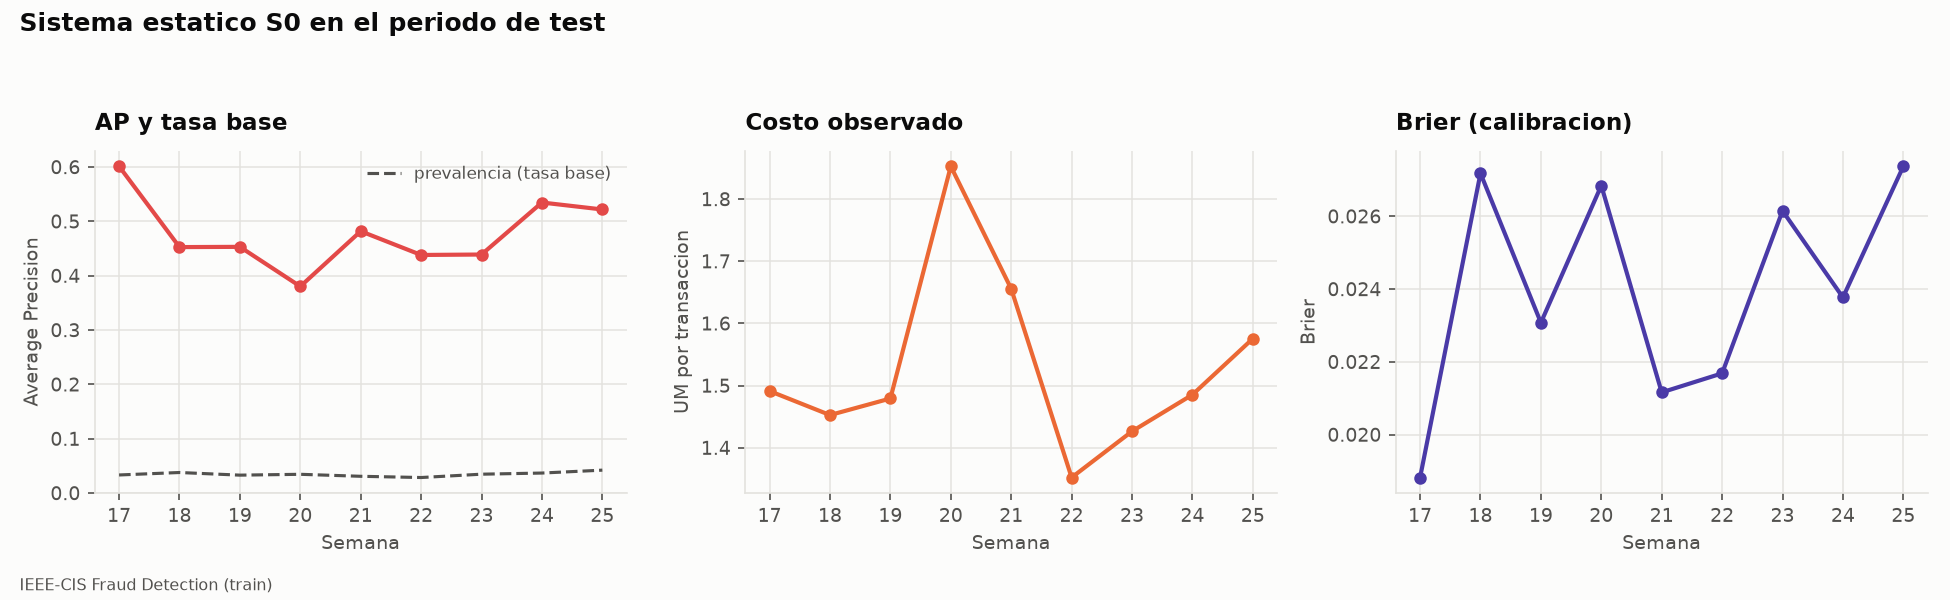

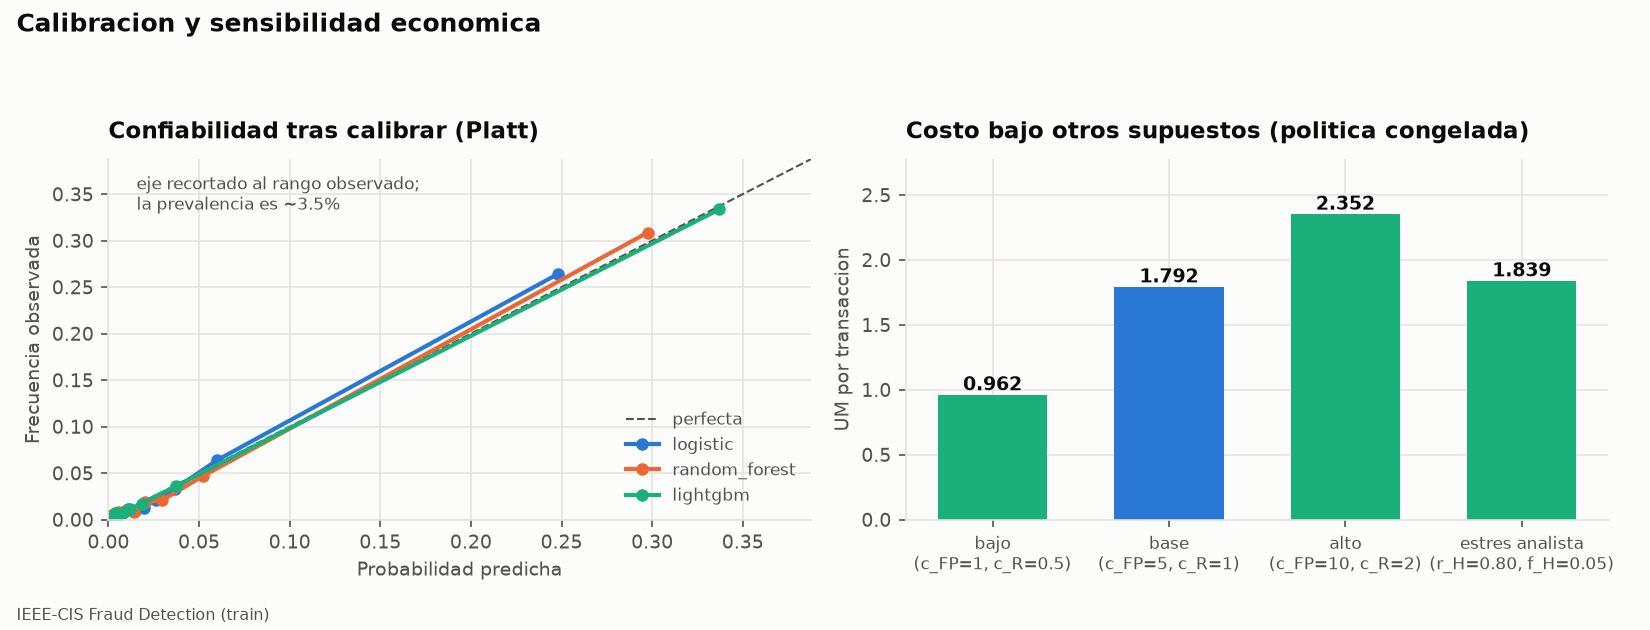

In [7]:
from IPython.display import Image, display
display(Image(filename=str(REPORTS / "figures" / "rendimiento_estatico.png")))
display(Image(filename=str(REPORTS / "figures" / "calibracion_costos.png")))

## 5. Lectura

Si el AP cae y la prevalencia no, el modelo perdió capacidad discriminante sobre
las mismas clases: es consistente con un cambio en P(y|X). La comparación temporal
por sí sola **no identifica causalmente** el drift, y el informe no lo afirma.